In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("motif_correlation_TATAWAW_3591898.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8448 entries, 0 to 8447
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  8448 non-null   int64 
 1   label       8448 non-null   int64 
 2   position    8448 non-null   int64 
 3   freq        8448 non-null   int64 
 4   dataset     8448 non-null   object
dtypes: int64(4), object(1)
memory usage: 330.1+ KB
None


In [27]:
rand_df = df[df["dataset"].isin(["rand"])]
df_without_rand = df[~df["dataset"].isin(["rand"])]


['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']
      Unnamed: 0  label  position  freq dataset
8192        8192      0         0  6352    rand
8193        8193      0         1  6408    rand
8194        8194      0         2  6334    rand
8195        8195      0         3  6333    rand
8196        8196      0         4  6368    rand
...          ...    ...       ...   ...     ...
8443        8443      0       251  6279    rand
8444        8444      0       252  6232    rand
8445        8445      0       253  6218    rand
8446        8446      0       254  6394    rand
8447        8447      0       255  6400    rand

[256 rows x 5 columns]


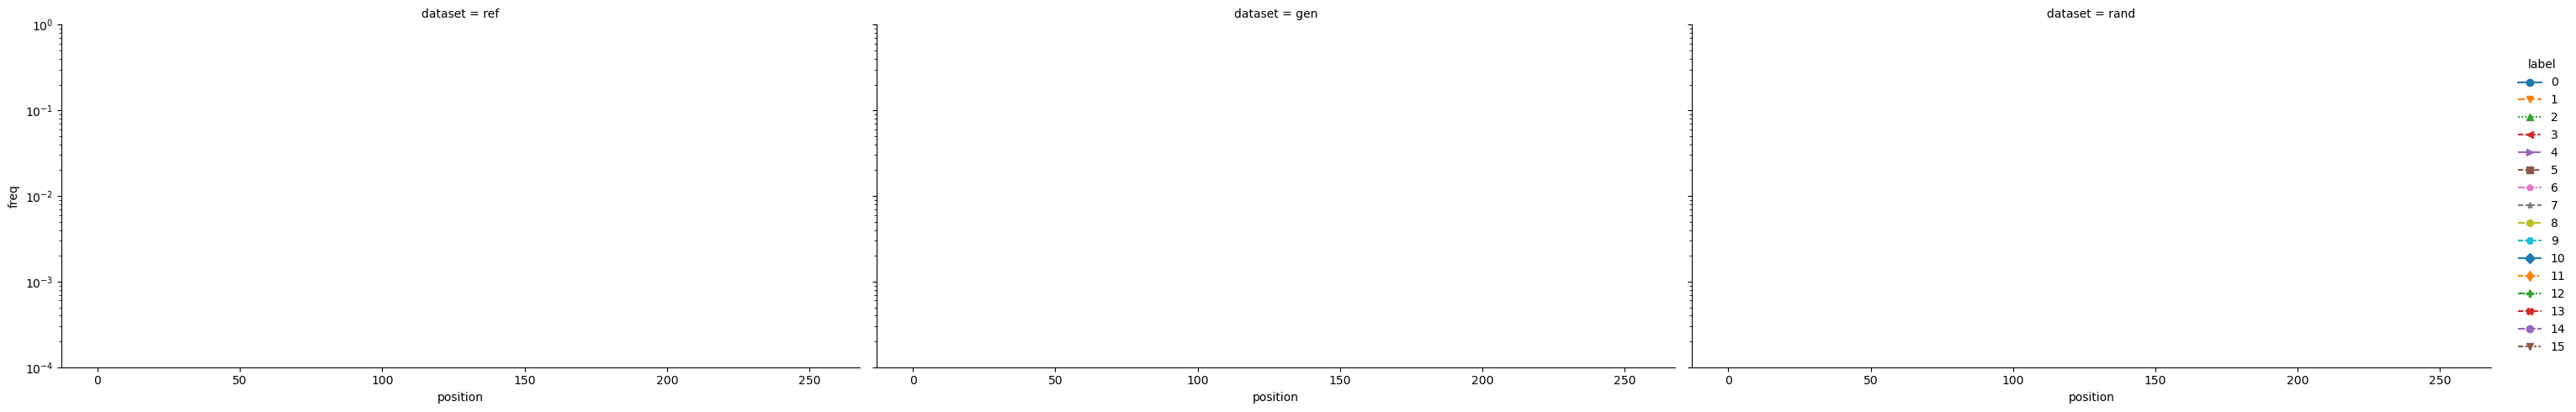

In [28]:
# Define a list of filled markers
filled_markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']

# Define a list of line styles
line_styles = ['-', '--', '-.', ':']

# Create a dictionary to map each label to a unique filled marker and line style
style_dict = {label: (filled_markers[i % len(filled_markers)], line_styles[i % len(line_styles)]) for i, label in enumerate(df['label'].unique())}
print([style_dict[label][1] for label in df['label'].unique()])
# Plot using seaborn with custom filled markers and line styles
g = sns.relplot(
    data=df,
    x="position",
    y="freq",
    hue="label",
    style="label",
    palette="tab10",
    col="dataset",
    kind="line",
    markers=[style_dict[label][0] for label in df['label'].unique()],
    #dashes=[style_dict[label][1] for label in df['label'].unique()],
    height=5,
    aspect=2
)
print(rand_df)
for ax in g.axes.flat:
    ax.scatter(rand_df["position"], rand_df["freq"], c="black", s=1)
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1)

plt.show()


Text(0.5, 0.98, 'Motif frequency in sequences with TATAWAW motif')

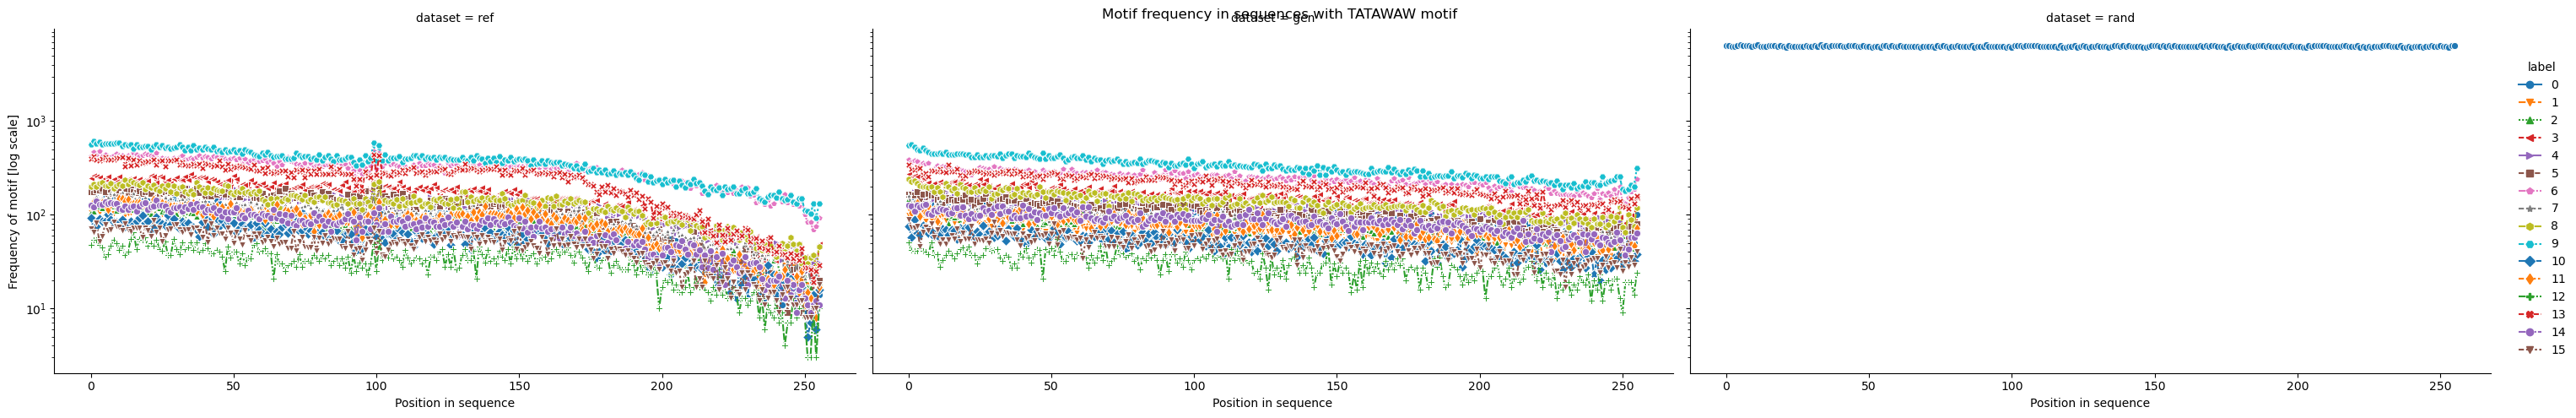

In [34]:
# Define a list of filled markers
filled_markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']

# Define a list of line styles
line_styles = ['-', '--', '-.', ':']

# Create a dictionary to map each label to a unique filled marker and line style
style_dict = {label: (filled_markers[i % len(filled_markers)], line_styles[i % len(line_styles)]) for i, label in enumerate(df['label'].unique())}
# Plot using seaborn with custom filled markers and line styles
g = sns.relplot(
    data=df,
    x="position",
    y="freq",
    hue="label",
    style="label",
    palette="tab10",
    col="dataset",
    kind="line",
    markers=[style_dict[label][0] for label in df['label'].unique()],
    #dashes=[style_dict[label][1] for label in df['label'].unique()],
    height=5,
    aspect=2
)
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_ylabel("Frequency of motif [log scale]")
    ax.set_xlabel("Position in sequence")
g.fig.suptitle("Motif frequency in sequences with TATAWAW motif")

In [46]:
df = pd.read_csv("generated_longest_alignment_100000.csv")
print(df.info())
df["label"] =df["label"].astype("category")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453057 entries, 0 to 453056
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Unnamed: 0   453057 non-null  int64
 1   label        453057 non-null  int64
 2   lcs_results  453057 non-null  int64
dtypes: int64(3)
memory usage: 10.4 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453057 entries, 0 to 453056
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   Unnamed: 0   453057 non-null  int64   
 1   label        453057 non-null  category
 2   lcs_results  453057 non-null  int64   
dtypes: category(1), int64(2)
memory usage: 7.3 MB
None


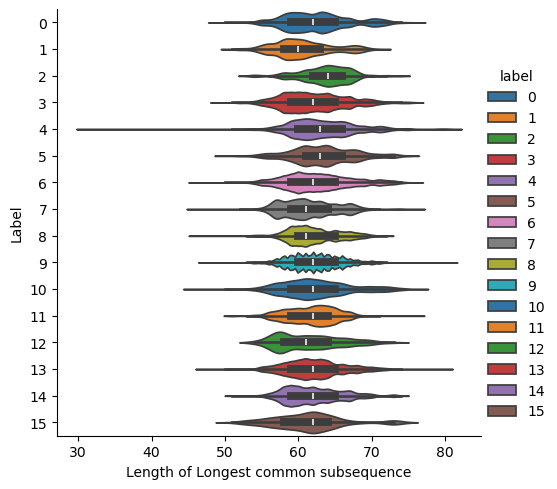

In [48]:
g1 = sns.catplot(data=df, x="lcs_results", y="label", hue="label", palette="tab10", kind="violin")
for ax in g1.axes.flat:
    ax.set_ylabel("Label")
    ax.set_xlabel("Length of Longest common subsequence") 